# Advanced Data Science: Deep Exploratory Data Analysis & Preparation
This notebook delves deeply into the dataset, exploring multi-dimensional relationships, identifying outliers, and rigorously preparing the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load the Data

In [2]:
df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Basic Information & Missing Values

In [3]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married   

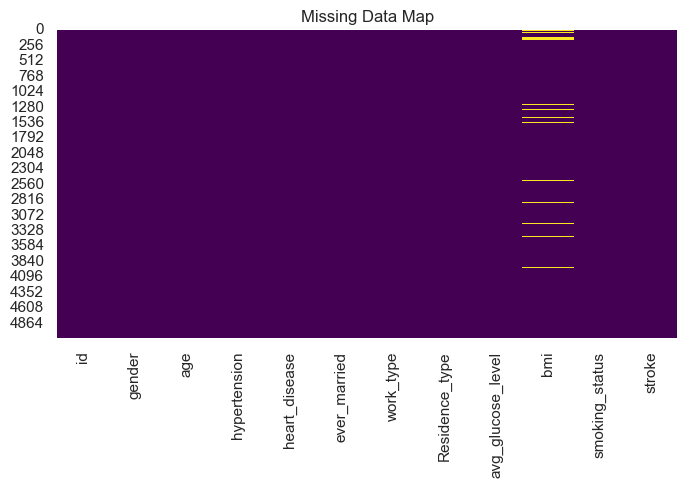

In [4]:
# Convert 'N/A' strings in 'bmi' to actual NaNs
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

# Visualize missing data
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Map')
plt.show()

## 3. Advanced Exploratory Data Analysis

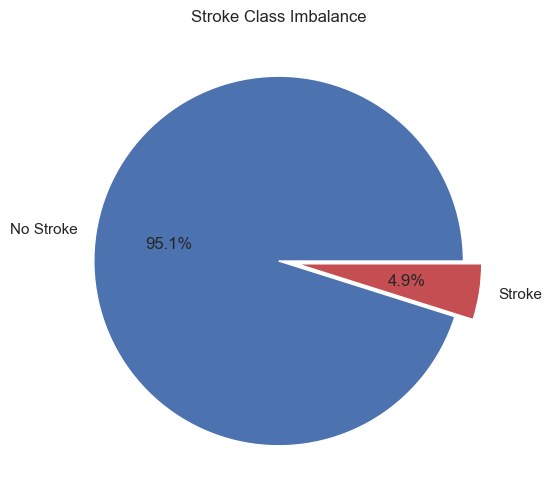

In [5]:
### Target Distribution (Imbalance)
plt.figure(figsize=(6, 6))
counts = df['stroke'].value_counts()
plt.pie(counts, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], explode=[0, 0.1])
plt.title('Stroke Class Imbalance')
plt.show()

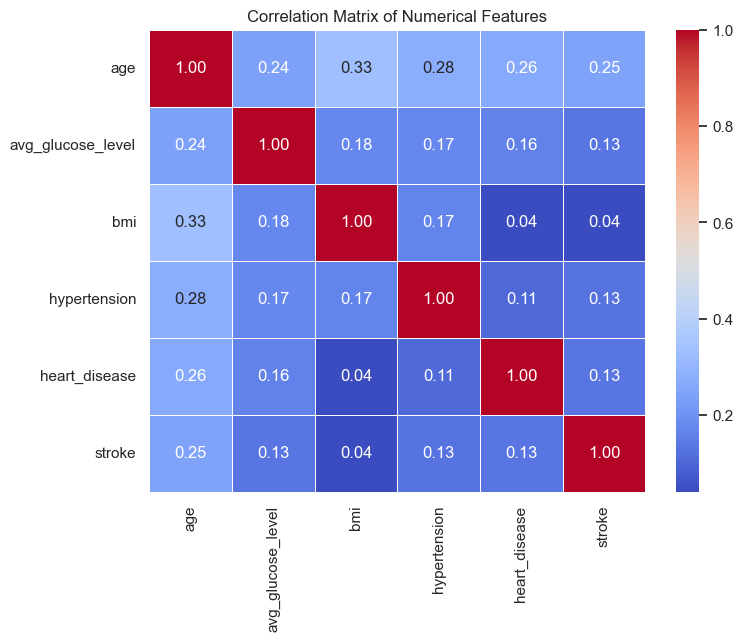

In [6]:
### Correlation Heatmap
numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

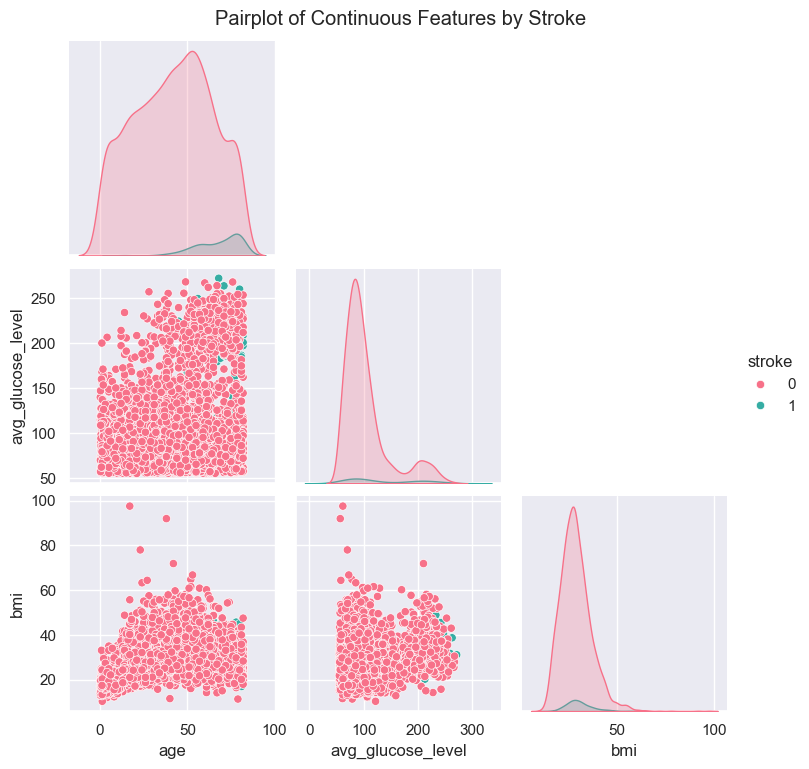

In [7]:
### Pairplot of Continuous Variables
cont_cols = ['age', 'avg_glucose_level', 'bmi', 'stroke']
sns.pairplot(df[cont_cols].dropna(), hue='stroke', palette='husl', corner=True)
plt.suptitle('Pairplot of Continuous Features by Stroke', y=1.02)
plt.show()

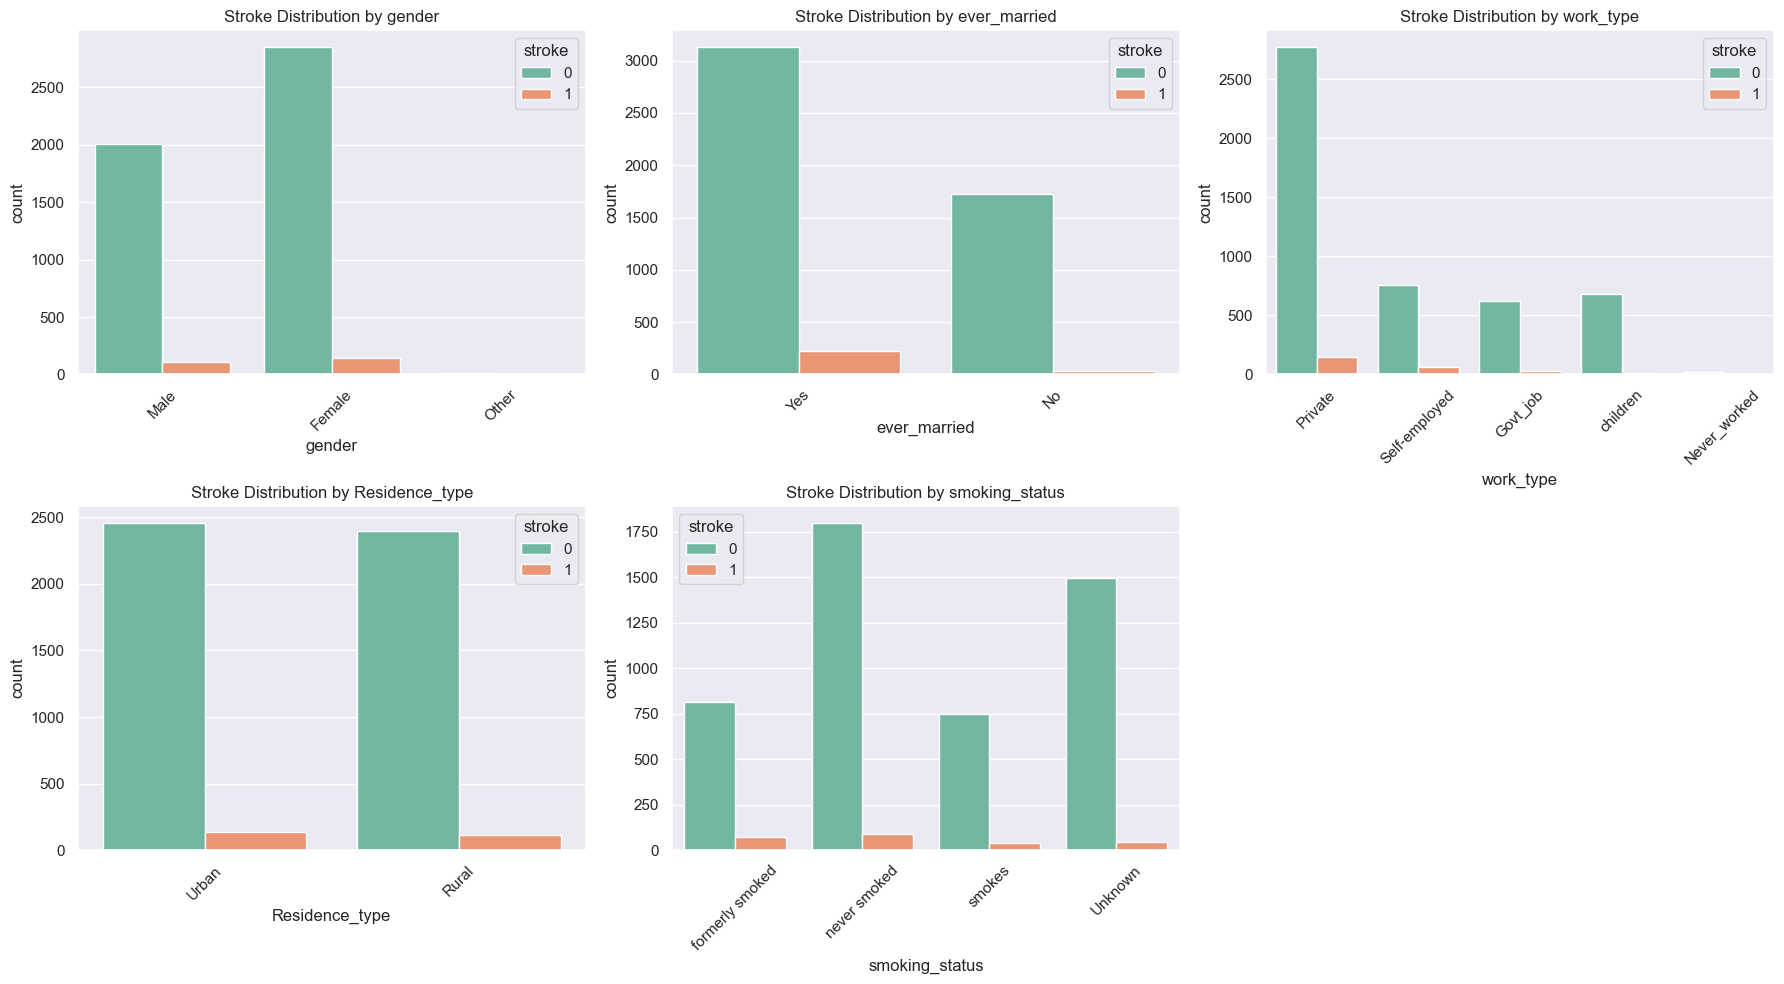

In [8]:
### Categorical Features Analysis
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue='stroke', ax=axes[i], palette='Set2')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'Stroke Distribution by {col}')
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 4. Outlier Detection & Handling

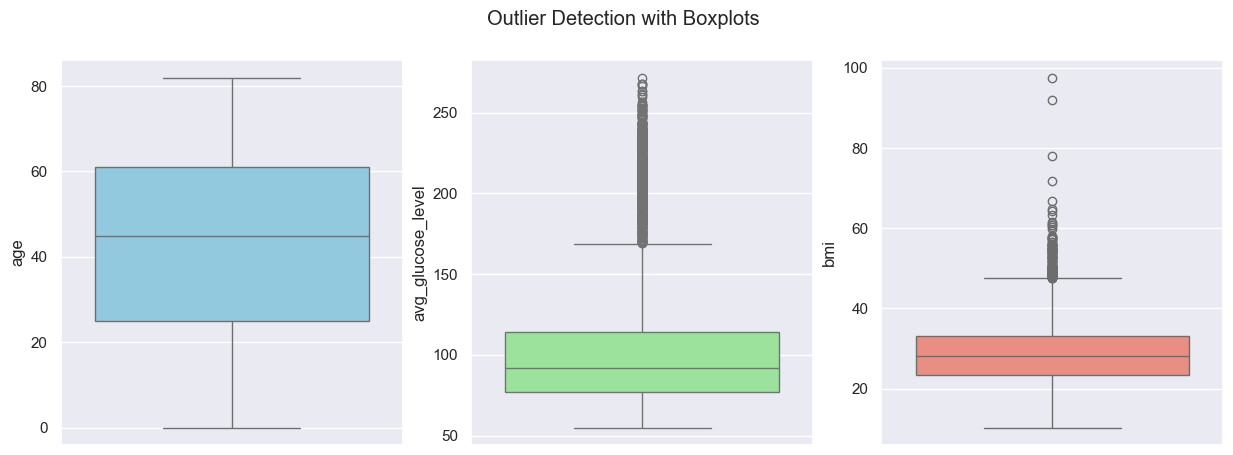

In [9]:
### Boxplots for Outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=df, y='age', ax=axes[0], color='skyblue')
sns.boxplot(data=df, y='avg_glucose_level', ax=axes[1], color='lightgreen')
sns.boxplot(data=df, y='bmi', ax=axes[2], color='salmon')
plt.suptitle('Outlier Detection with Boxplots')
plt.show()

In [10]:
# We can see significant outliers in avg_glucose_level and bmi.
# We will use IQR method to cap outliers to reduce their extreme effect without losing data.
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)

df['avg_glucose_level'] = cap_outliers(df['avg_glucose_level'])
df['bmi'] = cap_outliers(df['bmi'])

## 5. Data Cleaning & Imputation

In [11]:
# Drop 'id' column
df.drop('id', axis=1, inplace=True)

# Impute missing 'bmi' values with median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

# Remove 'Other' from gender
df = df[df['gender'] != 'Other']

print("Cleaned Dataset Info:")
df.info()

Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.0+ KB


C:\Users\acer\AppData\Local\Temp\ipykernel_19136\4080431122.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


## 6. Save Cleaned Data

In [12]:
cleaned_data_path = '../data/processed/stroke-data-cleaned.csv'
df.to_csv(cleaned_data_path, index=False)
print(f"Cleaned data saved to {cleaned_data_path}")

Cleaned data saved to ../data/processed/stroke-data-cleaned.csv
